In [ ]:
import os
import elevation

# 1. Define your specific folder
output_dir = './maps'
filename = 'Arizona-DEM.tif'
full_output_path = os.path.join(output_dir, filename)

# Ensure the folder actually exists
os.makedirs(output_dir, exist_ok=True)

# 2. Run the clip with the FULL path
az_bounds = (-114.816, 31.332, -109.045, 37.004)

print(f"Saving DEM to: {full_output_path}")

elevation.clip(
    bounds=az_bounds, 
    output=full_output_path, 
    max_download_tiles=50
)

# Clean the cache but keep your new TIF
elevation.clean()

# The cell below generates a map with the Spectral continuous color scheme to help display maximum definition in terms of elevation changes. Other cmap
# can be used as well, refer to matplotlib

Fetching 10m high-detail boundaries...
Clipping Arizona-DEM.tif...
Saving to Arizona_Spectral_Map_Label.png...


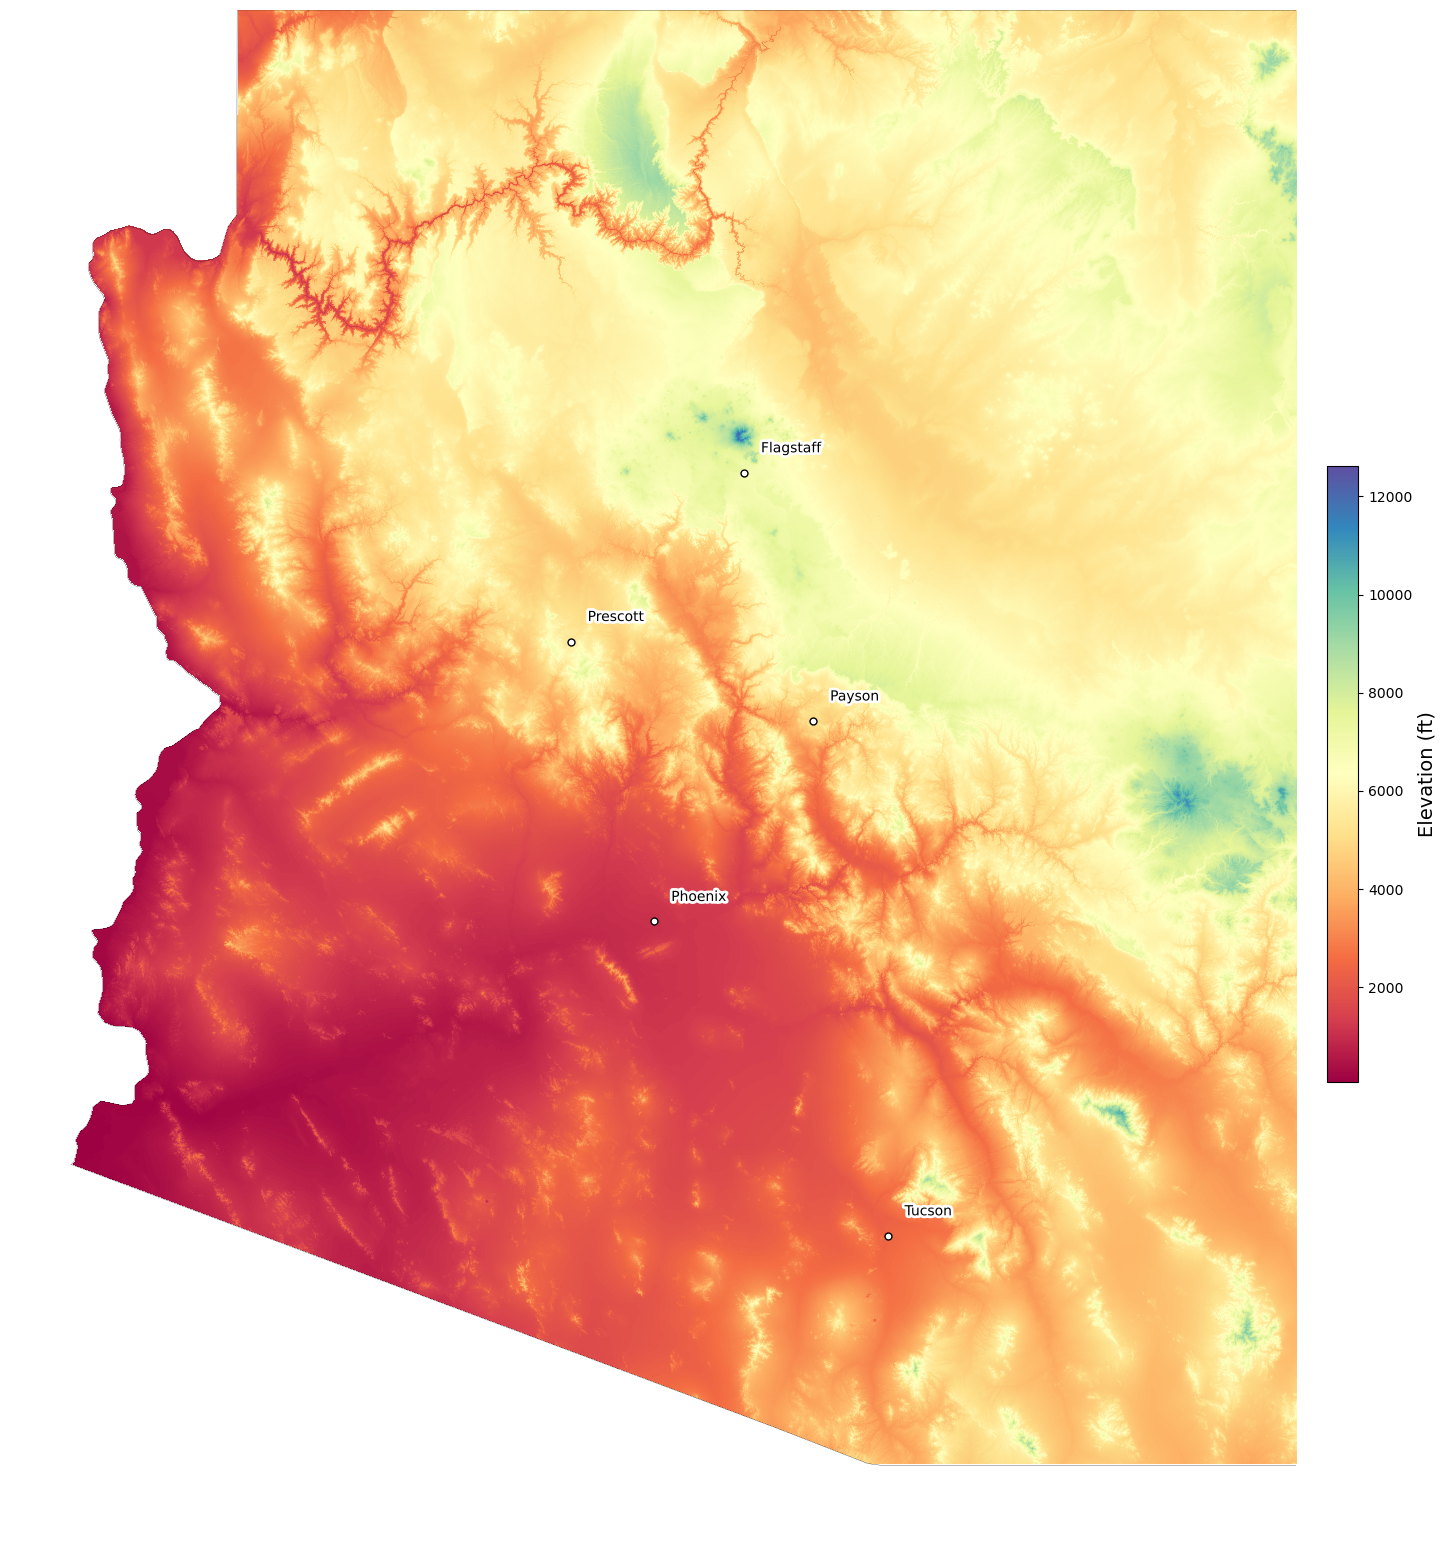

In [1]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Arizona-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

cities = {
    "Phoenix": (-112.074, 33.448),
    "Tucson": (-110.974, 32.222),
    "Flagstaff": (-111.651, 35.198),
    "Prescott": (-112.468, 34.540),
    "Payson": (-111.325, 34.230)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (Cartopy Mirror Method)
print("Fetching 10m high-detail boundaries...")
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
usa = gpd.read_file(shpfilename)

# Filter for Arizona
# Natural Earth 10m uses 'name' for the state name
arizona = usa[usa['name'] == 'Arizona']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    arizona = arizona.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, arizona.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Convert to feet
    elevation = elevation * 3.28084
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# 2. COLORMAP SETUP
true_arizona_colors = [
    (0.0,  "#D2B48C"),  # Tan (Desert)
    (0.2,  "#B06D45"),  # Copper (High Desert)
    (0.4,  "#8B8B4C"),  # Sage (Transition)
    (0.6,  "#2D5A27"),  # Pine Green (The Rim)
    (0.85, "#708090"),  # Slate (Rocks)
    (1.0,  "#FFFFFF")   # White (Peaks)
]
custom_terrain = mcolors.LinearSegmentedColormap.from_list("AZ_True", true_arizona_colors)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Use interpolation='none' for maximum edge sharpness
im = ax.imshow(elevation, extent=extent, cmap='Spectral', origin='upper', interpolation='none')

# Draw the high-detail border
arizona.boundary.plot(ax=ax, color='black', linewidth=0.2, zorder=10)

#4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])

# 5. EXPORT
cb = plt.colorbar(im, shrink=0.4, pad=0.02)
cb.set_label('Elevation (ft)', fontsize=14)
ax.axis('off')

output_filename = "Arizona_Spectral_Map_Label.png"
print(f"Saving to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)

plt.show()

# The cell below tries to emulate a 'natural' color scheme to AZ

Fetching 10m high-detail boundaries...
Clipping Arizona-DEM.tif...
Saving to Arizona_True_color_Map_Label.png...


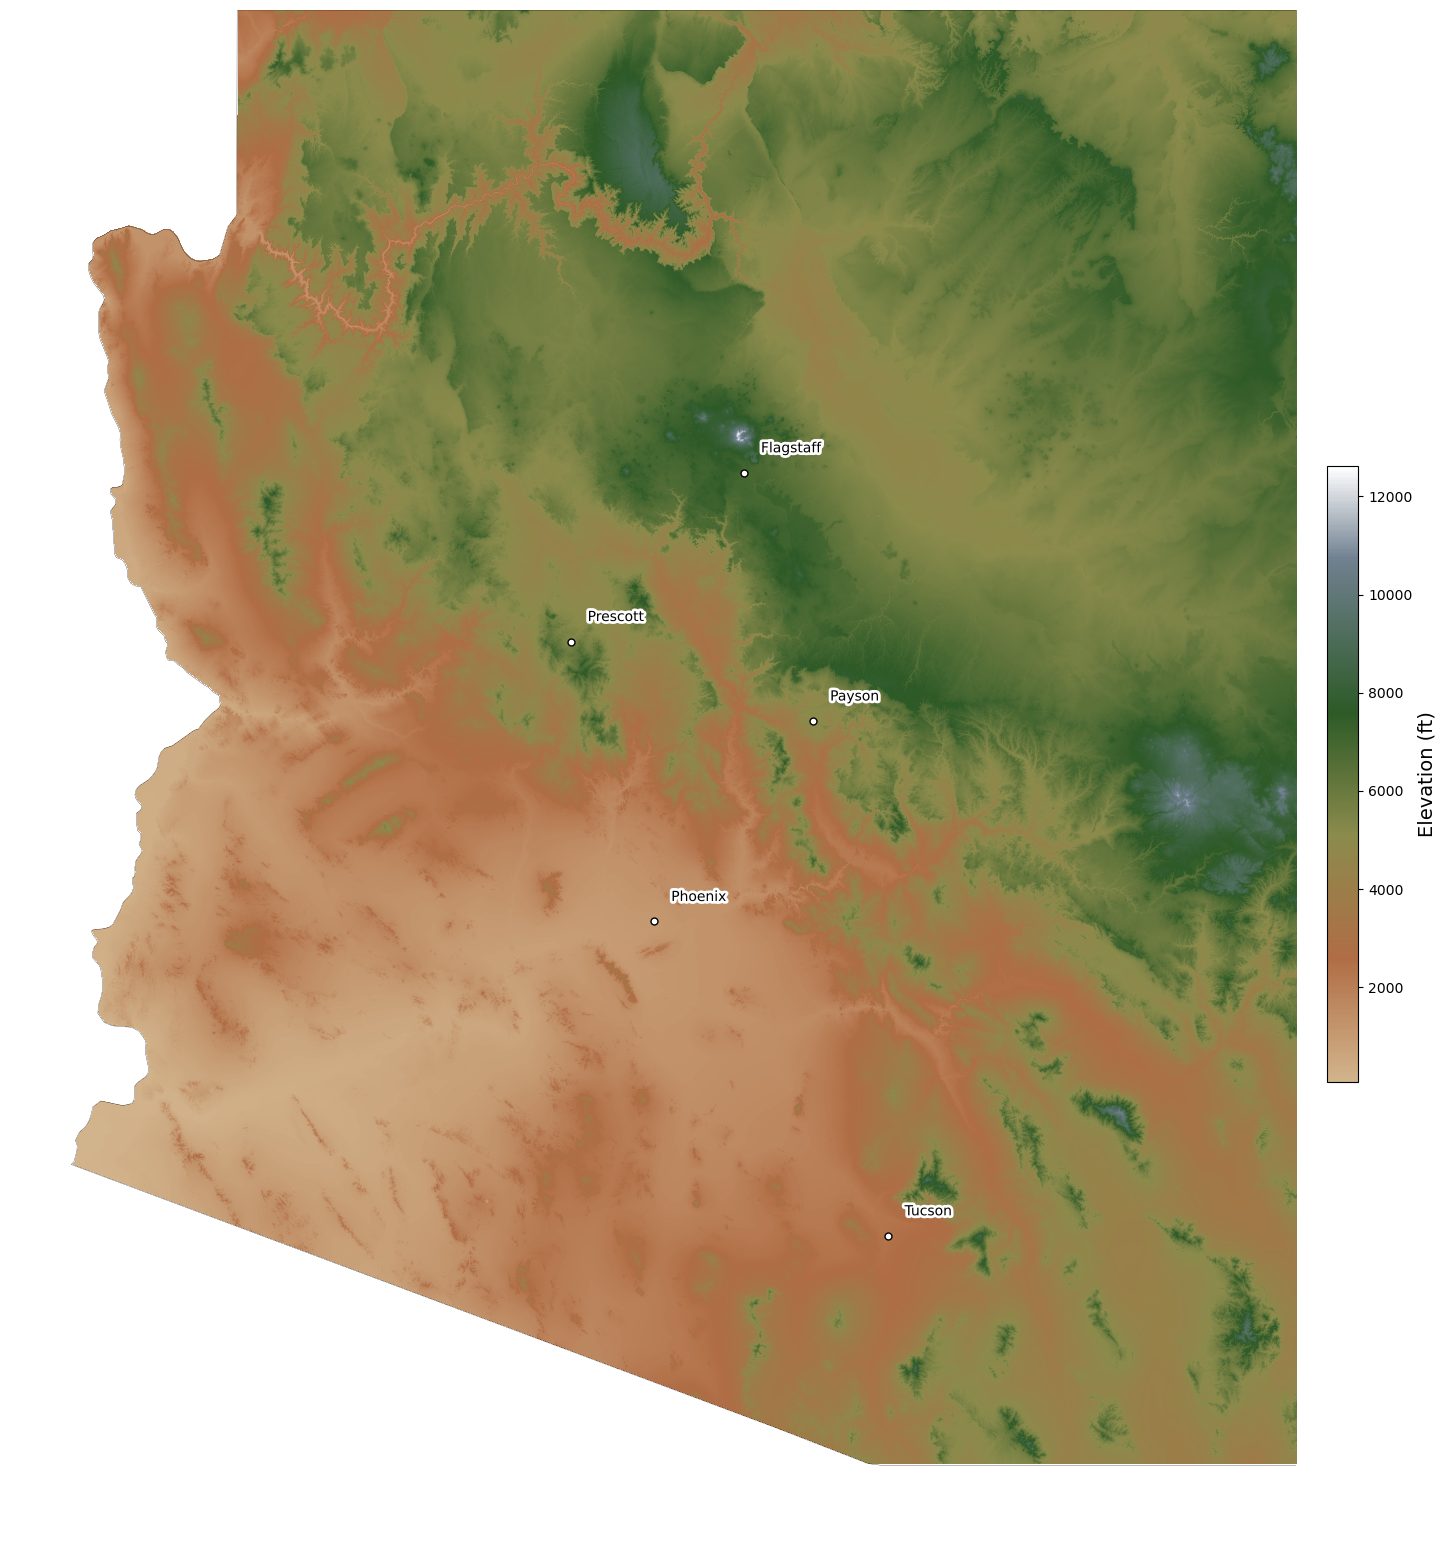

In [2]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Arizona-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

cities = {
    "Phoenix": (-112.074, 33.448),
    "Tucson": (-110.974, 32.222),
    "Flagstaff": (-111.651, 35.198),
    "Prescott": (-112.468, 34.540),
    "Payson": (-111.325, 34.230)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (Cartopy Mirror Method)
print("Fetching 10m high-detail boundaries...")
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
usa = gpd.read_file(shpfilename)

# Filter for Arizona
# Natural Earth 10m uses 'name' for the state name
arizona = usa[usa['name'] == 'Arizona']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    arizona = arizona.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, arizona.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Convert to feet
    elevation = elevation * 3.28084
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# 2. COLORMAP SETUP
true_arizona_colors = [
    (0.0,  "#D2B48C"),  # Tan (Desert)
    (0.2,  "#B06D45"),  # Copper (High Desert)
    (0.4,  "#8B8B4C"),  # Sage (Transition)
    (0.6,  "#2D5A27"),  # Pine Green (The Rim)
    (0.85, "#708090"),  # Slate (Rocks)
    (1.0,  "#FFFFFF")   # White (Peaks)
]
custom_terrain = mcolors.LinearSegmentedColormap.from_list("AZ_True", true_arizona_colors)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Use interpolation='none' for maximum edge sharpness
im = ax.imshow(elevation, extent=extent, cmap=custom_terrain, origin='upper', interpolation='none')

# Draw the high-detail border
arizona.boundary.plot(ax=ax, color='black', linewidth=0.2, zorder=10)

#4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])

# 5. EXPORT
cb = plt.colorbar(im, shrink=0.4, pad=0.02)
cb.set_label('Elevation (ft)', fontsize=14)
ax.axis('off')

output_filename = "Arizona_True_color_Map_Label.png"
print(f"Saving to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)

plt.show()

# The cell below uses a categorical scheme for coloring elevation changes to bring out the elevation bands of the state in a more dramatic fashion

Fetching 10m high-detail boundaries...
Clipping Arizona-DEM.tif...
Saving to Arizona_HighDetail_Categorical_Map.png...


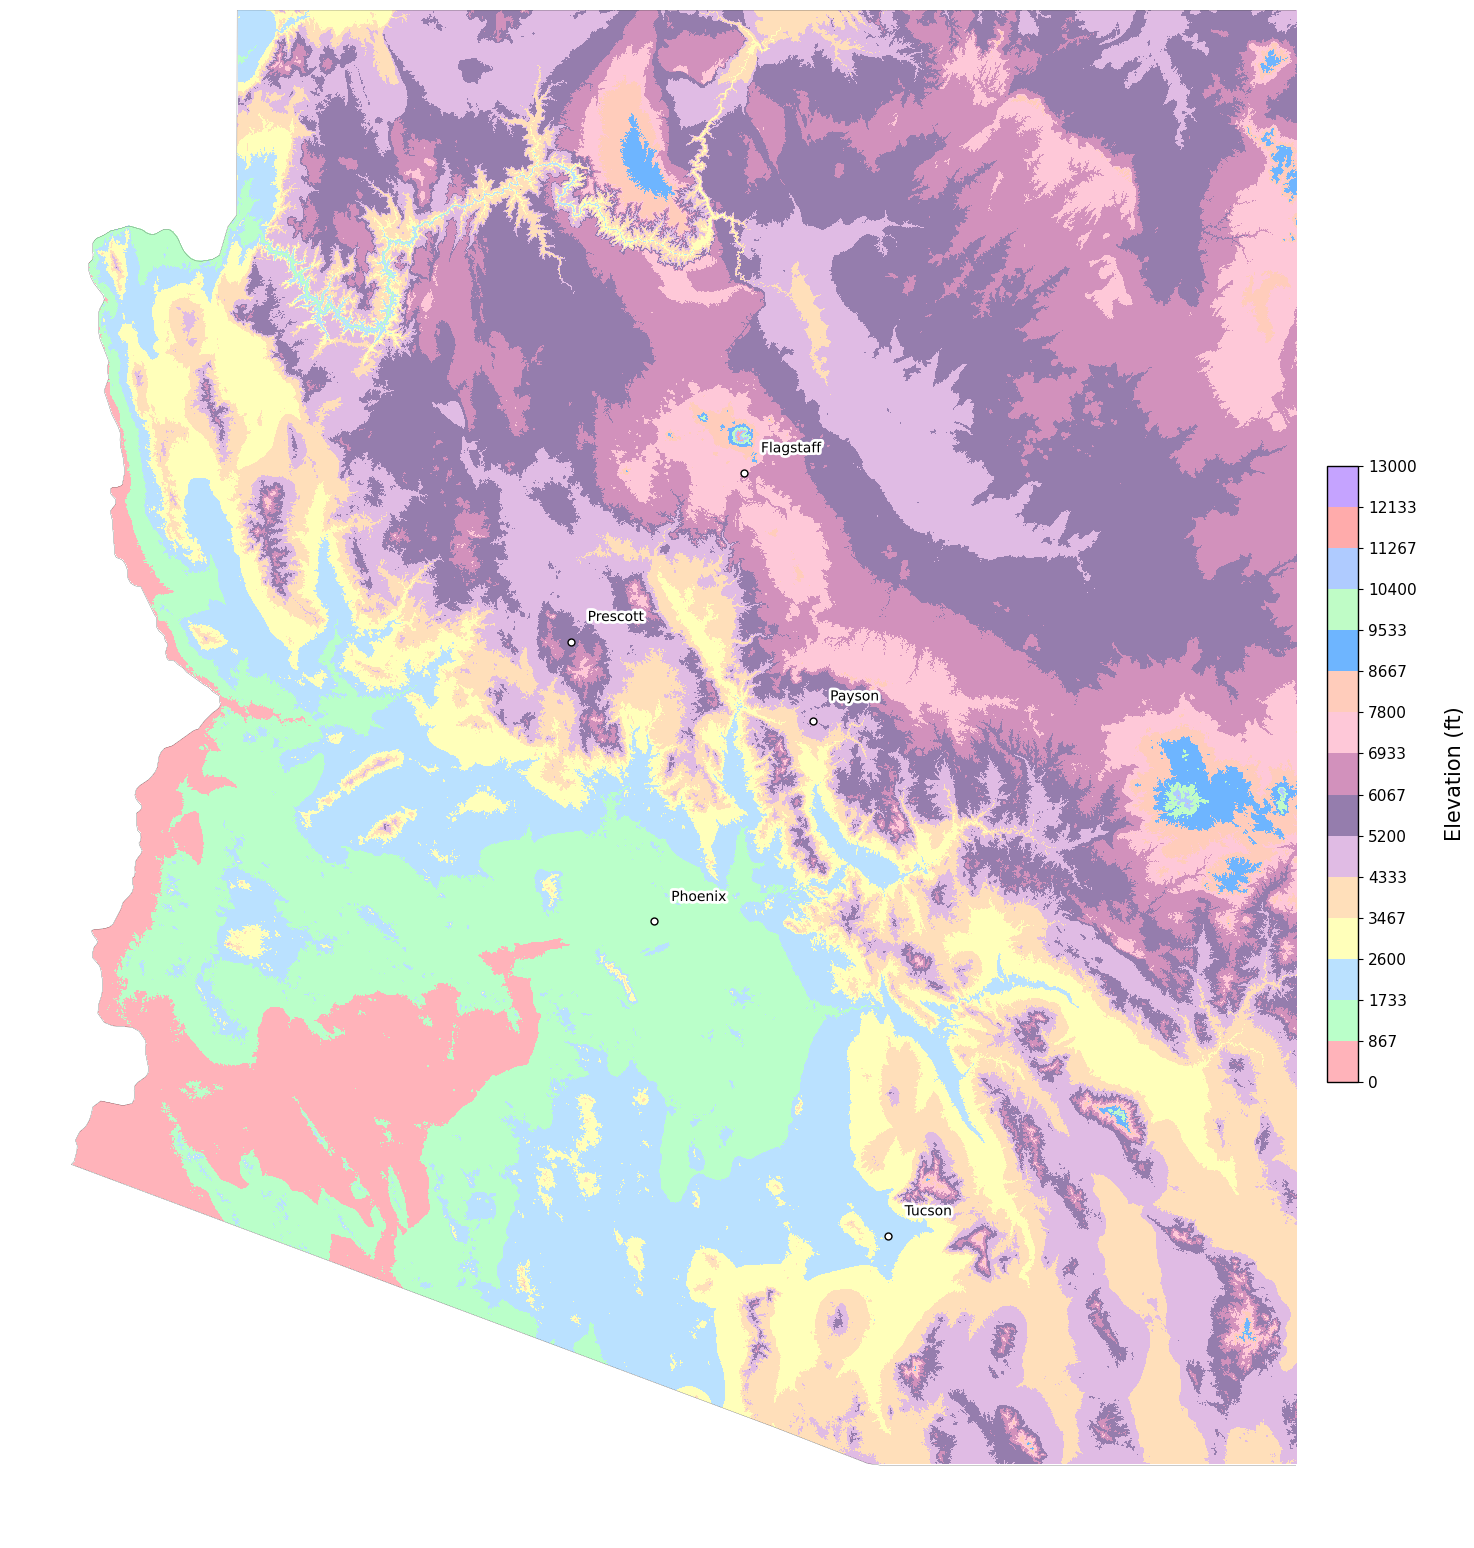

In [3]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Arizona-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

cities = {
    "Phoenix": (-112.074, 33.448),
    "Tucson": (-110.974, 32.222),
    "Flagstaff": (-111.651, 35.198),
    "Prescott": (-112.468, 34.540),
    "Payson": (-111.325, 34.230)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (Cartopy Mirror Method)
print("Fetching 10m high-detail boundaries...")
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
usa = gpd.read_file(shpfilename)

# Filter for Arizona
# Natural Earth 10m uses 'name' for the state name
arizona = usa[usa['name'] == 'Arizona']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    arizona = arizona.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, arizona.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Convert to feet
    elevation = elevation * 3.28084
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)


# 1. Define 16 bounds for 15 discrete steps (0 to 13,000 ft)
# Each step is roughly 866 feet.
bounds = np.linspace(0, 13000, 16)

# 2. 15 Distinctive Pastel/High-Contrast Colors
# We alternate hues (Pink -> Teal -> Gold) to ensure the "steps" stay visible
distinguishable_15 = [
    "#FFB3BA", "#BAFFC9", "#BAE1FF", "#FFFFBA", # Row 1: Soft Pink, Green, Blue, Yellow
    "#FFDFBA", "#E0BBE4", "#957DAD", "#D291BC", # Row 2: Peach, Lavender, Purple, Mauve
    "#FEC8D8", "#FFCCBB", "#6EB5FF", "#BFFCC6", # Row 3: Rose, Apricot, Sky, Mint
    "#AFCBFF", "#FFABAB", "#C5A3FF"             # Row 4: Periwinkle, Coral, Lilac
]

# 3. Create the Categorical Colormap
cmap_15 = mcolors.ListedColormap(distinguishable_15)
norm_15 = mcolors.BoundaryNorm(bounds, cmap_15.N)

# --- Section 3: PLOTTING ---
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f7f7f7') # Soft light-grey background

im = ax.imshow(elevation, 
               extent=extent, 
               cmap=cmap_15, 
               norm=norm_15, 
               origin='upper', 
               interpolation='none') 

# Add a dark grey border for a clean, modern look
arizona.boundary.plot(ax=ax, color='#444444', linewidth=0.2, zorder=10)

#4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])

# --- THE CLEAN LEGEND ---
cb = plt.colorbar(
    im, 
    ax=ax, 
    shrink=0.4, 
    pad=0.02, 
    spacing='uniform', 
    ticks=bounds
)

cb.set_label('Elevation (ft)', fontsize=15, labelpad=20)
cb.ax.tick_params(labelsize=11)
cb.outline.set_linewidth(1)

ax.axis('off')

output_filename = "Arizona_HighDetail_Categorical_Map.png"
print(f"Saving to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)

plt.show()

# In the cell below, we use hillshade and a light source to try and mimic the sun and shadows to create a 3D effect to the terrain
# using the Spectral_r continous color scheme

Fetching 10m high-detail boundaries...
Clipping Arizona-DEM.tif...
Saving to Arizona_Spectral_Hillshade.png...


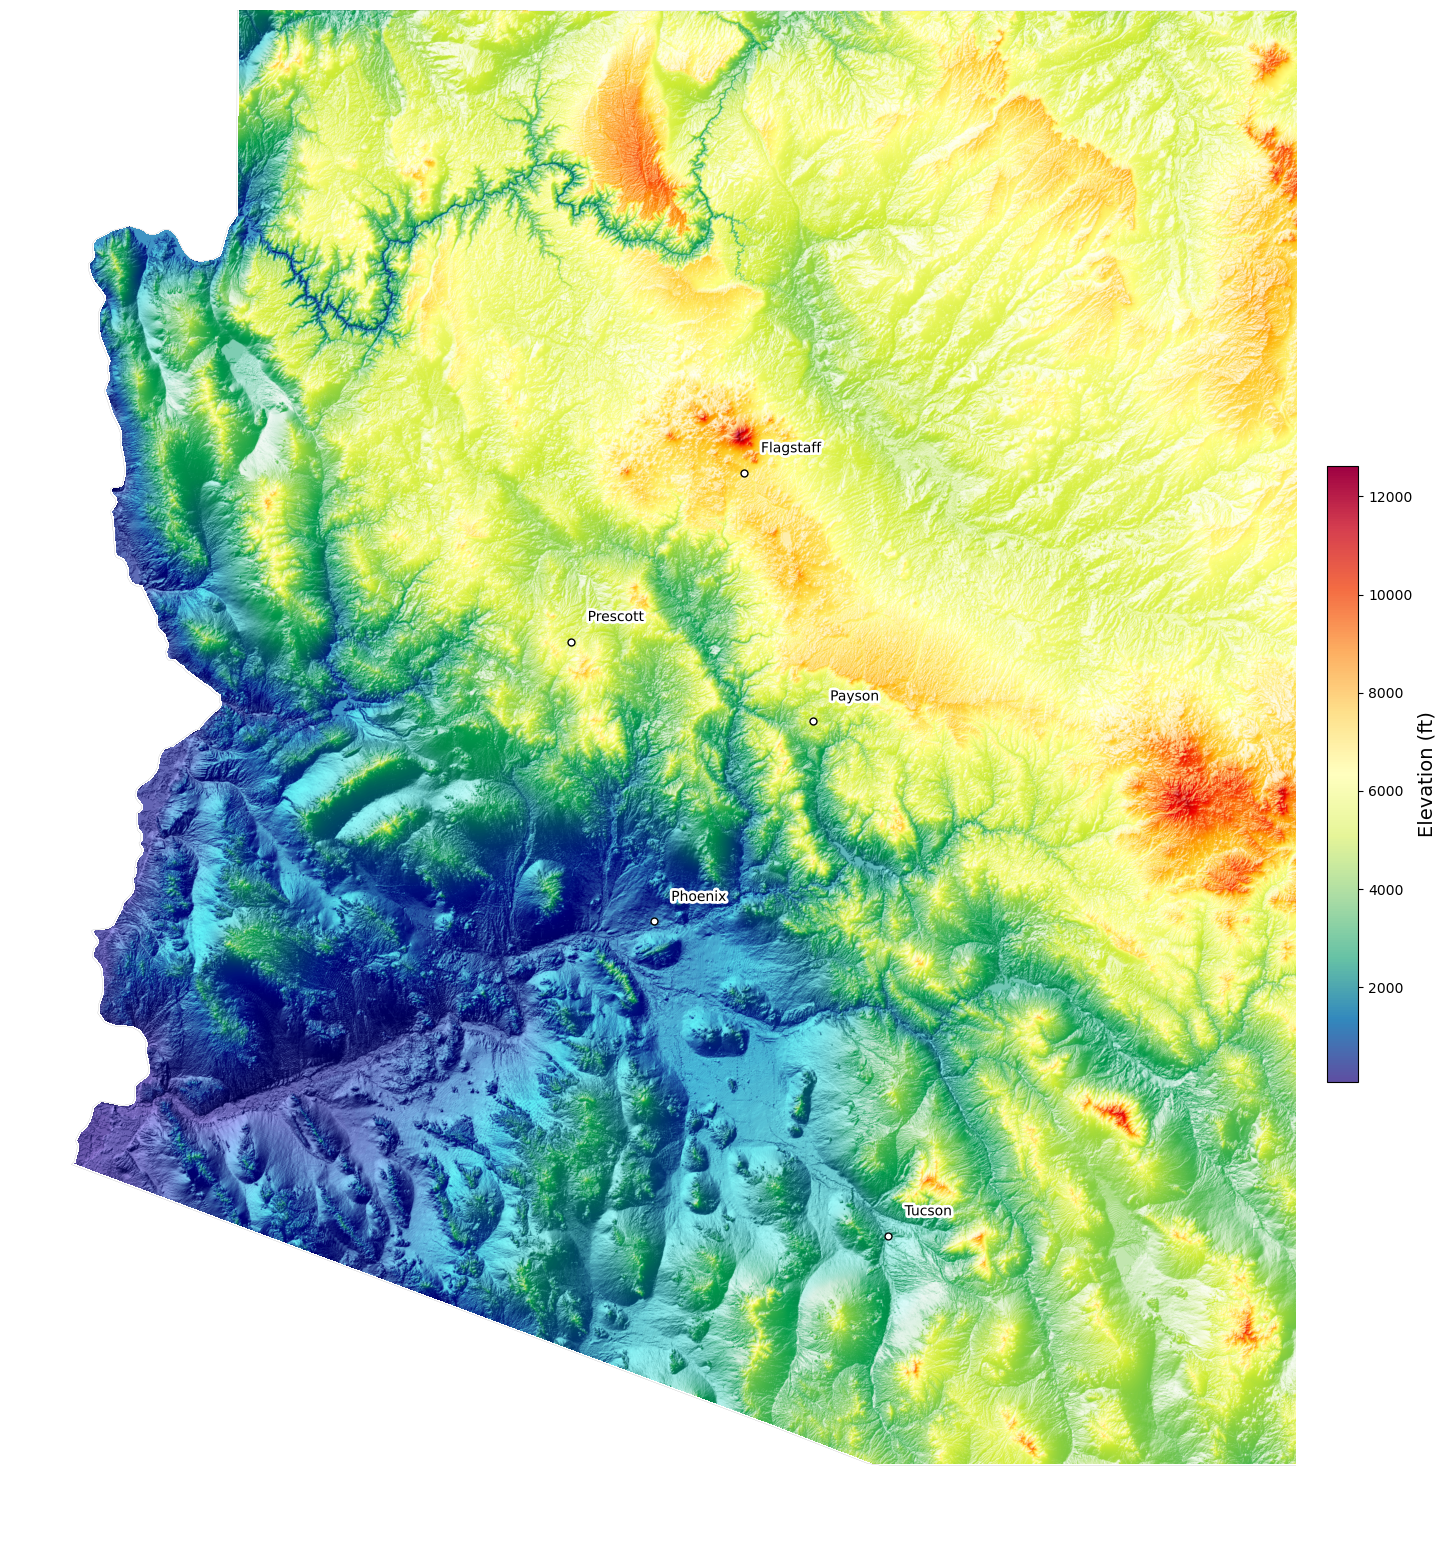

In [4]:
###hillshadeimport rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
from matplotlib.colors import LightSource
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Arizona-DEM.tif' 
DOWNSAMPLE_FACTOR = 3  # 1 for maximum pixel detail

cities = {
    "Phoenix": (-112.074, 33.448),
    "Tucson": (-110.974, 32.222),
    "Flagstaff": (-111.651, 35.198),
    "Prescott": (-112.468, 34.540),
    "Payson": (-111.325, 34.230)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (Cartopy Mirror Method)
print("Fetching 10m high-detail boundaries...")
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
usa = gpd.read_file(shpfilename)

# Filter for Arizona
# Natural Earth 10m uses 'name' for the state name
arizona = usa[usa['name'] == 'Arizona']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    arizona = arizona.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, arizona.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Convert to feet
    elevation = elevation * 3.28084
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# 1. Create the LightSource
# azdeg: azimuth (direction of sun), altdeg: altitude (height of sun)
ls = LightSource(azdeg=315, altdeg=35)

# 2. Generate the Hillshade
# we use the raw elevation data (not nan-filled) for better shading results
hillshade = ls.hillshade(elevation, vert_exag=1.0) 

# 3. Combine Color + Shading (The "3D" Magic)
# This blends the Spectral colormap with the light/shadow texture
rgb = ls.shade(elevation, cmap=plt.get_cmap('Spectral_r'), blend_mode='overlay', vert_exag=1.0,
               vmin=np.nanmin(elevation), vmax=np.nanmax(elevation))

# rgb = ls.shade(elevation, cmap=plt.get_cmap('Spectral_r'), blend_mode='soft', vert_exag=1.0,
#                vmin=np.nanmin(elevation), vmax=np.nanmax(elevation))

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Plot the combined RGB image
ax.imshow(rgb, extent=extent, origin='upper', interpolation='bilinear')

# Draw the high-detail border
arizona.boundary.plot(ax=ax, color='black', linewidth=0.1, alpha=0.6, zorder=10)

#4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])


# 1. Create a "ScalarMappable" for the colorbar to reference
sm = plt.cm.ScalarMappable(cmap='Spectral_r', 
                           norm=plt.Normalize(vmin=np.nanmin(elevation), 
                                              vmax=np.nanmax(elevation)))
sm._A = [] 

# 2. Create the colorbar using the ScalarMappable instead of 'im'
cb = plt.colorbar(sm, shrink=0.4, pad=0.02, ax=ax)
cb.set_label('Elevation (ft)', fontsize=14)
ax.axis('off')

output_filename = "Arizona_Spectral_Hillshade.png"
print(f"Saving to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)

plt.show()